# State of Data Brasil — Análise de Gênero (2021–2024)

> **Objetivo:** Investigar desigualdades de gênero no mercado de dados brasileiro.  
> **Recorte:** Gênero × Remuneração, Faixa Salarial e Senioridade.  
> **Split ML:** Treino = 2021–2023 (com features de IA de 2023) · Teste = 2024 (com features de IA de 2024)


---
## Seção 0 — Imports e Carregamento da base de dados

In [75]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from xgboost import XGBClassifier
import shap

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

SEED  = 42
np.random.seed(SEED)
ALPHA = 0.05
print('OK')

OK


In [76]:
dfs_raw = {
    '2021': pd.read_csv('data/state_of_data_2021.csv', low_memory=False),
    '2022': pd.read_csv('data/state_of_data_2022.csv', low_memory=False),
    '2023': pd.read_csv('data/state_of_data_2023.csv', low_memory=False),
    '2024': pd.read_csv('data/state_of_data_2024.csv', low_memory=False),
}
for ano, df_raw in dfs_raw.items():
    print(f'{ano}: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')

2021: 2,645 linhas × 356 colunas
2022: 4,271 linhas × 353 colunas
2023: 5,293 linhas × 399 colunas
2024: 5,217 linhas × 403 colunas


### 0.1 Mapeamento de colunas por ano

In [77]:
COLUMN_MAPPING = {
    '2021': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_a ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_e ', 'Estado onde mora')",
        'uf':               "('P1_e_a ', 'uf onde mora')",
        'regiao':           "('P1_e_b ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_g_b ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_h ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_i ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_q ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2022': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_p ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2023': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_r ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2024': {
        'idade':            '1.a_idade',
        'faixa_idade':      '1.a.1_faixa_idade',
        'genero':           '1.b_genero',
        'estado':           '1.i_estado_onde_mora',
        'uf':               '1.i.1_uf_onde_mora',
        'regiao':           '1.i.2_regiao_onde_mora',
        'regiao_origem':    '1.k.2_regiao_de_origem',
        'nivel_ensino':     '1.l_nivel_de_ensino',
        'area_formacao':    '1.m_área_de_formação',
        'situacao':         '2.a_situação_de_trabalho',
        'setor':            '2.b_setor',
        'cargo':            '2.f_cargo_atual',
        'gestor':           '2.d_atua_como_gestor',
        'nivel':            '2.g_nivel',
        'faixa_salarial':   '2.h_faixa_salarial',
        'tempo_area_dados': '2.i_tempo_de_experiencia_em_dados',
        'tempo_area_ti':    '2.j_tempo_de_experiencia_em_ti',
        'modalidade':       '2.r_modelo_de_trabalho_atual',
    }
}

IA_COLS = {
    '2023': {
        'ia_prioridade_empresa':      "('P3_e ', 'AI Generativa é uma prioridade em sua empresa?')",
        'ia_tipos_uso_gestao':        "('P3_f ', 'Tipos de uso de AI Generativa e LLMs na empresa')",
        'ia_motivos_nao_usar':        "('P3_g ', 'Motivos que levam a empresa a não usar AI Genrativa e LLMs')",
        'ia_tipo_uso_pessoal':        "('P4_l ', 'Qual o tipo de uso de AI Generativa e LLMs na empresa')",
        'ia_usa_chatgpt_no_trabalho': "('P4_m ', 'Utiliza ChatGPT ou LLMs no trabalho?')",
    },
    '2024': {
        'ia_prioridade_empresa':      '3.e_ai_generativa_e_llm_é_uma_prioridade?',
        'ia_tipos_uso_gestao':        '3.f_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_motivos_nao_usar':        '3.g_motivos_para_não_usar_ai_generativa_e_llm',
        'ia_tipo_uso_pessoal':        '4.l_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_usa_chatgpt_no_trabalho': '4.m_usa_chatgpt_ou_copilot_no_trabalho?',
    },
}

IA_FEATS_ALL = [
    'ia_prioridade_empresa',
    'ia_tipos_uso_gestao',
    'ia_motivos_nao_usar',
    'ia_tipo_uso_pessoal',
    'ia_usa_chatgpt_no_trabalho'
]

### 0.2 Mapeamentos ordinais e de categorias

In [78]:
FAIXA_SALARIAL_MAP = {
    'de R$ 1.001/mês a R$ 2.000/mês':   'R$1k-2k',
    'de R$ 2.001/mês a R$ 3.000/mês':   'R$2k-3k',
    'de R$ 2.001/mês a R$ 3000/mês':    'R$2k-3k',
    'de R$ 3.001/mês a R$ 4.000/mês':   'R$3k-4k',
    'de R$ 4.001/mês a R$ 6.000/mês':   'R$4k-6k',
    'de R$ 6.001/mês a R$ 8.000/mês':   'R$6k-8k',
    'de R$ 8.001/mês a R$ 12.000/mês':  'R$8k-12k',
    'de R$ 12.001/mês a R$ 16.000/mês': 'R$12k-16k',
    'de R$ 16.001/mês a R$ 20.000/mês': 'R$16k-20k',
    'de R$ 20.001/mês a R$ 25.000/mês': 'R$20k-25k',
    'de R$ 25.001/mês a R$ 30.000/mês': 'R$25k-30k',
    'de R$ 30.001/mês a R$ 40.000/mês': 'R$30k-40k',
    'Acima de R$ 40.001/mês':           'R$40k+',
}
FAIXA_SALARIAL_ORDEM = [
    'R$1k-2k', 'R$2k-3k', 'R$3k-4k', 'R$4k-6k', 'R$6k-8k',
    'R$8k-12k', 'R$12k-16k', 'R$16k-20k', 'R$20k-25k',
    'R$25k-30k', 'R$30k-40k', 'R$40k+',
]
NIVEL_ENSINO_ORDEM = [
    'Não tenho graduação formal', 'Estudante de Graduação',
    'Graduação/Bacharelado', 'Especialização Lato Sensu',
    'Mestrado', 'Doutorado ou Phd',
]
#NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior', 'Gestor']
NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior']  # leakage
NIVEL_SENIORIDADE_EDA    = ['Júnior', 'Pleno', 'Sênior', 'Gestor']  # EDA

CARGO_MAP = {
    'Analista de Dados/Data Analyst':                    'Analista de Dados',
    'Analista de BI/BI Analyst':                         'Analista de Dados',
    'Analista de BI/BI Analyst/Analytics Engineer':      'Analista de Dados',
    'Analista de Negócios/Business Analyst':             'Analista de Dados',
    'Analista de Inteligência de Mercado/Market Intelligence': 'Analista de Dados',
    'Analista de Marketing':                             'Analista de Dados',
    'Analista Administrativo':                           'Analista de Dados',
    'Estatístico':                                       'Analista de Dados',
    'Economista':                                        'Analista de Dados',
    'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect': 'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer':                 'Engenheiro de Dados',
    'Analytics Engineer':                                'Engenheiro de Dados',
    'Arquiteto de Dados':                                'Engenheiro de Dados',
    'Arquiteto de dados':                                'Engenheiro de Dados',
    'DBA/Administrador de Banco de Dados':               'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect':  'Engenheiro de Dados',
    'Arquiteto de Dados/Data Architect':                 'Engenheiro de Dados',
    'Cientista de Dados/Data Scientist':                 'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer':        'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer': 'Cientista de Dados',
    'Professor':                                         'Professor/Pesquisador',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Product Manager/ Product Owner (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Desenvolvedor',
    'Desenvolvedor ou Engenheiro de Software':           'Desenvolvedor',
    'Analista de Sistemas/Analista de TI':               'Desenvolvedor',
    'Analista de Suporte/Analista Técnico':              'Desenvolvedor',
    'Suporte Técnico':                                   'Desenvolvedor',
    'Técnico':                                           'Desenvolvedor',
    'Outra Opção':                                       'Outro',
    'Outras Engenharias (não inclui dev)':               'Outro',
}
AREA_FORMACAO_MAP = {
    'Computação / Engenharia de Software / Sistemas de Informação/ TI': 'Computação / TI',
    'Outras Engenharias': 'Engenharia (outras)',
    'Outras Engenharias (não incluir engenharia de software ou TI)': 'Engenharia (outras)',
    'Economia/ Administração / Contabilidade / Finanças/ Negócios': 'Economia / Adm / Finanças',
    'Economia/ Administração / Contabilidade / Finanças': 'Economia / Adm / Finanças',
    'Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais': 'Estatística / Matemática',
    'Estatística/ Matemática / Matemática Computacional': 'Estatística / Matemática',
    'Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde': 'Ciências da Saúde',
    'Ciências Biológicas/Farmácia/Medicina/Área da Saúde': 'Ciências da Saúde',
    'Marketing / Publicidade / Comunicação / Jornalismo': 'Marketing / Comunicação',
    'Marketing / Publicidade / Comunicação / Jornalismo / Ciências Sociais': 'Marketing / Comunicação',
    'Outra opção': 'Outras',
}
SITUACAO_MAP = {
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil':      'Remoto p/ exterior',
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil (PJ)': 'Remoto p/ exterior',
    'Desempregado, buscando recolocação':                                   'Desempregado',
    'Desempregado e não estou buscando recolocação':                        'Desempregado',
    'Somente Estudante (graduação)':                                        'Somente Estudante',
    'Somente Estudante (pós-graduação)':                                    'Somente Estudante',
    'Prefiro não informar':                                                  None,
}

REGIAO_MAP = {
    'Centro_Oeste': 'Centro-Oeste', 'Centro Oeste': 'Centro-Oeste',
    'centro-oeste': 'Centro-Oeste', 'Centro-oeste': 'Centro-Oeste',
    'nordeste': 'Nordeste', 'norte': 'Norte',
    'sudeste': 'Sudeste',  'sul':    'Sul',
    'Exterior': None, 'Prefiro não informar': None,
}

ANOS     = ['2021', '2022', '2023', '2024']
REGIOES = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']

CORES_GENERO = {'Masculino': '#517493', 'Feminino': '#64313E'}
CORES_REGIAO = {
    'Sudeste':      '#2563EB',
    'Sul':          '#16A34A',
    'Nordeste':     '#EA580C',
    'Centro-Oeste': '#9333EA',
    'Norte':        '#CA8A04',
}
TEMPLATE = 'plotly_white'

---
## Seção 1 — Pipeline de pré-processamento

In [79]:
def build_year_dataframe(df_raw: pd.DataFrame, year: str) -> pd.DataFrame:

    # COLUNAS BASE
    
    base_map = COLUMN_MAPPING[year]

    cols_base = {
        old: new
        for new, old in base_map.items()
        if old in df_raw.columns
    }

    df = df_raw[list(cols_base.keys())].rename(columns=cols_base).copy()

    
    # COLUNAS DE IA (2023/2024)
    
    if year in IA_COLS:

        ia_map = IA_COLS[year]

        cols_ia = {
            old: new
            for new, old in ia_map.items()
            if old in df_raw.columns
        }
        
        ia_df = (df_raw[list(cols_ia.keys())].rename(columns=cols_ia))

        df = pd.concat([df, ia_df], axis=1)

    # ANO
   
    df.insert(0, 'ano_pesquisa', year)

    return df
    

In [80]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:

    
    # GÊNERO
    
    df = df[df['genero'].isin(['Masculino', 'Feminino'])].copy()

    # NÍVEL DE ENSINO
    
    df['nivel_ensino'] = (
        df['nivel_ensino']
        .replace({
            'Pós-graduação': 'Especialização Lato Sensu',
            'Prefiro não informar': np.nan
        })
    )

    df['nivel_ensino'] = pd.Categorical(
        df['nivel_ensino'],
        categories=NIVEL_ENSINO_ORDEM,
        ordered=True
    )

    # FAIXA SALARIAL
    
    df['faixa_salarial'] = (
        df['faixa_salarial']
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .replace(FAIXA_SALARIAL_MAP)
    )

    df['faixa_salarial'] = pd.Categorical(
        df['faixa_salarial'],
        categories=FAIXA_SALARIAL_ORDEM,
        ordered=True
    )

    # CARGO / ÁREA / REGIÃO
    
    df['cargo'] = df['cargo'].replace(CARGO_MAP)

    df['area_formacao'] = (
        df['area_formacao']
        .replace(AREA_FORMACAO_MAP)
    )

    df['regiao'] = (
        df['regiao']
        .replace(REGIAO_MAP)
    )

    # SENIORIDADE
    
    df['nivel'] = pd.Categorical(
        df['nivel'].where(
            df['nivel'].isin(NIVEL_SENIORIDADE_ORDEM)
        ),
        categories=NIVEL_SENIORIDADE_ORDEM,
        ordered=True
    )

    # GESTOR (0/1)
    
    df['gestor'] = (
        df['gestor']
        .replace({
            'Sim': 1,
            'Não': 0,
            'sim': 1,
            'não': 0
        })
        .pipe(pd.to_numeric, errors='coerce')
        .fillna(0)
        .astype(int)
    )

    # SITUAÇÃO
    
    df['situacao'] = (
        df['situacao']
        .replace(SITUACAO_MAP)
    )

    df = df[df['situacao'].notna()]

    return df.reset_index(drop=True)

In [81]:
def run_pipeline(dfs_raw: dict) -> pd.DataFrame:
    """
    Constrói o dataset unificado a partir dos CSVs brutos.
    Etapas: renomear colunas → concatenar anos → limpar.
    """
    frames = []
    for year in ANOS:
        print(f'  {year}...')
        frames.append(build_year_dataframe(dfs_raw[year], year))

    df = pd.concat(frames, ignore_index=True)
    df = preprocess(df)
    return df


In [82]:
df = run_pipeline(dfs_raw)

  2021...
  2022...
  2023...
  2024...


In [83]:
# SPLIT TREINO / TESTE

df_train = df[df['ano_pesquisa'] != '2024'].copy()

df_test = df[df['ano_pesquisa'] == '2024'].copy()

# SAVE

df.to_parquet(
    'data/df_full.parquet',
    index=False
)

df_train.to_parquet(
    'data/df_train.parquet',
    index=False
)

df_test.to_parquet(
    'data/df_test.parquet',
    index=False
)

# SHAPES

print(f' df_full: {df.shape}')
print(f' treino: {df_train.shape}')
print(f' teste: {df_test.shape}')

# -----------------------------
# COBERTURA IA
# -----------------------------
print('\nCobertura IA:')

for nome, subset in [
    ('Treino', df_train),
    ('Teste', df_test)
]:

    cobertura = (
        subset[IA_FEATS_ALL]
        .notna()
        .any(axis=1)
        .mean() * 100
    )

    print(f'{nome}: {cobertura:.1f}%')

 df_full: (17295, 24)
 treino: (12117, 24)
 teste: (5178, 24)

Cobertura IA:
Treino: 38.3%
Teste: 89.5%


---
## Seção 2 — Análise Exploratória de Dados EDA

Cada visualização responde uma pergunta diferente, todas longitudinais por ano sem agregação e sem redundância. 

- 2.1 Representatividade feminina ao longo dos anos
- 2.2 Senioridade por gênero
- 2.3 Distribuição de cargos por gênero
- 2.4 Diferença salarial entre gêneros
- 2.5 Escolaridade por gênero
- 2.6 Área de formação por gênero
- 2.7 Distribuição de Experiência na Área de Dados por Gênero
- 2.8 Modalidade de trabalho por gênero
- 2.9 Adoção de IA por gênero
- 2.10 Análise regional da participação feminina


In [84]:
def fmt(fig, title, height=450, **kw):
    fig.update_layout(
        title=title, template=TEMPLATE, height=height,
        legend=dict(orientation='h', y=1.02, x=1, xanchor='right'),
        **kw,
    )
    return fig


def dedup_legend(fig):
    seen = set()
    for t in fig.data:
        t.showlegend = t.name not in seen
        seen.add(t.name)
    return fig


def subplots_pct_fem(df, col, order, title, height=420):
    """
    Subplots 1x4 (um por ano): % feminino por categoria.
    Exibe n em cada barra.
    """
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)

    for i, ano in enumerate(ANOS, 1):
        sub = df[df['ano_pesquisa'] == ano]
        tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
        n   = tab.sum(axis=1)
        pct = tab.get('Feminino', 0) / n.replace(0, np.nan) * 100

        fig.add_trace(go.Bar(
            y=pct.index,
            x=pct.values,
            orientation='h',
            marker_color=CORES_GENERO['Feminino'],
            text=[f'{v:.0f}%<br><sub>n={int(ni)}</sub>'
                  if not np.isnan(v) else '' for v, ni in zip(pct, n)],
            textposition='outside',
            showlegend=False,
        ), row=1, col=i)

        fig.update_xaxes(range=[0, 75], ticksuffix='%', row=1, col=i)

    return fmt(fig, title, height=height)


def subplots_piramide(df, col, order, title, height=420):
    """
    Subplots 1x4: pirâmide bilateral — % dentro de cada gênero por categoria.
    """
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)

    for i, ano in enumerate(ANOS, 1):
        sub = df[df['ano_pesquisa'] == ano]
        tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
        pct = tab.div(tab.sum(), axis=1) * 100

        for genero in CORES_GENERO:
            vals = pct.get(genero, pd.Series(0, index=pct.index))
            x    = -vals if genero == 'Feminino' else vals
            fig.add_trace(go.Bar(
                y=pct.index, x=x, orientation='h',
                name=genero, legendgroup=genero,
                marker_color=CORES_GENERO[genero],
                text=[f'{v:.0f}%' for v in vals],
                textposition='auto',
            ), row=1, col=i)

        fig.add_shape(
            type='line', x0=0, x1=0,
            y0=-0.5, y1=len(order) - 0.5,
            line=dict(color='black', dash='dot', width=1),
            row=1, col=i,
        )
        fig.update_xaxes(
            range=[-55, 55],
            tickvals=[-40, -20, 0, 20, 40],
            ticktext=['40%', '20%', '0', '20%', '40%'],
            row=1, col=i,
        )

    dedup_legend(fig)
    return fmt(fig, title, height=height, barmode='relative')


### 2.1 — Representatividade feminina ao longo dos anos



In [85]:
tab = (
    pd.crosstab(df['ano_pesquisa'], df['genero'])
    .reindex(ANOS)
)

pct_fem = tab['Feminino'].div(tab.sum(axis=1)).mul(100)

fig = go.Figure(
    go.Scatter(
        x=ANOS,
        y=pct_fem,
        mode='lines+markers+text',
        text=[
            f'{v:.1f}%<br><sub>n={int(n)}</sub>'
            for v, n in zip(pct_fem, tab.sum(axis=1))
        ],
        textposition='top center',
        line=dict(
            color=CORES_GENERO['Feminino'],
            width=3,
        ),
        marker=dict(size=10),
    )
)

fig = fmt(
    fig,
    'Representatividade Feminina por Ano (2021–2024)',
    height=360,
)

fig.update_yaxes(
    title='% Feminino',
    ticksuffix='%',
    range=[0, 40],
)

fig.show()
#fig.write_image('2_1_representatividade_feminina.png')

### 2.2 — Senioridade por gênero



In [86]:
fig = subplots_piramide(
    df, 'nivel', NIVEL_SENIORIDADE_EDA,
    'Senioridade por Gênero (2021–2024)',
)
fig.show()
#fig.write_image('2_2_senioridade_genero.png')

### 2.3 — Cargo por gênero

In [ ]:
CARGO_ORDEM = [
    'Analista de Dados', 'Cientista de Dados', 'Engenheiro de Dados',
    'Desenvolvedor', 'Product Manager', 'Professor/Pesquisador', 'Outro',
]

fig = subplots_pct_fem(
    df, 'cargo', CARGO_ORDEM,
    '% Feminino por Cargo (2021–2024)',
    height=440,
)
fig.show()

#PERCENTUAL SOBREPOSTO NA BARRA E N MANTEM FORA OBS, ATENTAR P COR (NUMERO BRANCO COM CONTRASTE)


### 2.4 — Distribuição salarial por gênero

In [ ]:
fig = subplots_piramide(
    df, 'faixa_salarial', FAIXA_SALARIAL_ORDEM,
    'Distribuição Salarial por Gênero — % dentro de cada gênero (2021–2024)',
    height=560,
)
fig.show()

#AJUSTAR ORDEM LEGENDA 


### 2.5 — Escolaridade por gênero

In [89]:
fig = subplots_pct_fem(
    df, 'nivel_ensino', NIVEL_ENSINO_ORDEM,
    '% Feminino por Nível de Ensino (2021–2024)',
    height=440,
)
fig.show()


In [90]:
# Distribuição de escolaridade dentro de cada gênero (% por nível)
tab_ens = pd.crosstab(df['nivel_ensino'], df['genero'])
tab_ens_pct = tab_ens.div(tab_ens.sum(axis=0), axis=1) * 100
tab_ens_pct = tab_ens_pct.reindex(NIVEL_ENSINO_ORDEM)

fig = go.Figure()
for genero in ['Feminino', 'Masculino']:
    fig.add_trace(go.Bar(
        name=genero,
        x=tab_ens_pct.index,
        y=tab_ens_pct[genero],
        marker_color=CORES_GENERO[genero],
        text=[f"{v:.1f}%" for v in tab_ens_pct[genero]],
        textposition='outside',
    ))
fig = fmt(
    fig,
    'Distribuição de Escolaridade por Gênero (% dentro de cada gênero)',
    height=420,
    barmode='group',
)
fig.update_yaxes(title='%', ticksuffix='%')
fig.show()


### 2.6 — Área de formação por gênero

In [91]:
AREA_ORDEM = [
    'Computação / TI', 'Engenharia (outras)', 'Estatística / Matemática',
    'Economia / Adm / Finanças', 'Ciências da Saúde', 'Marketing / Comunicação', 'Outras',
]

fig = subplots_pct_fem(
    df, 'area_formacao', AREA_ORDEM,
    '% Feminino por Área de Formação (2021–2024)',
    height=440,
)
fig.show()

### 2.7 — Experiência na área de dados por gênero

In [92]:
TEMPO_ORDEM = [
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 2 a 3 anos',
    'de 3 a 4 anos',
    'de 4 a 5 anos',
    'de 5 a 6 anos',
    'de 6 a 7 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]

# Filtra apenas categorias presentes nos dados (mantém a ordem definida acima)
tempo_valido = [t for t in TEMPO_ORDEM if t in df['tempo_area_dados'].dropna().unique()]

fig = subplots_pct_fem(
    df[df['tempo_area_dados'].isin(tempo_valido)],
    'tempo_area_dados',
    tempo_valido,
    '% Feminino por Tempo de Experiência em Dados (2021–2024)',
    height=440,
)
fig.show()
#fig.write_image('figures/2_7_experiencia_genero.png')


### 2.8 — Modalidade de trabalho por gênero

In [93]:
MODALIDADE_ORDEM = sorted(df['modalidade'].dropna().unique().tolist())

fig = subplots_pct_fem(
    df[df['modalidade'].notna()],
    'modalidade',
    MODALIDADE_ORDEM,
    '% Feminino por Modalidade de Trabalho (2021–2024)',
    height=360,
)
fig.show()
#fig.write_image('figures/2_8_modalidade_genero.png')


### 2.9 — Adoção de IA generativa por gênero 

In [94]:
IA_POSITIVO = {
    'ia_prioridade_empresa': [
        'Sim, está entre nossas principais prioridades para os próximos 2-4 anos (com discussões de iniciativas e orçamentos de curto a médio prazo).',
        'Sim, é nossa principal prioridade como empresa (com foco executivo significativo e alocação de orçamento relevante).',
    ],
    'ia_tipos_uso_gestao': [
        'Colaboradores utilizando soluções baseadas em AI Generativa (como o ChatGPT por exemplo) de forma independente, com o objetivo de melhorar sua produtividade no dia a dia, sem um direcionamento centralizado.',
        'Uma ou mais equipes testando e aplicando soluções de AI Generativa e LLMs, com o objetivo de propor melhorias e inovações para impulsionar a diferenciação de produtos oferecidos para os clientes finais (exemplo: novos recursos, produtos, serviços etc).',
    ],
    'ia_motivos_nao_usar': None,  # presença já indica barreira — qualquer resposta = 1
    'ia_tipo_uso_pessoal': [
        'Colaboradores utilizando soluções baseadas em AI Generativa (como o ChatGPT por exemplo) de forma independente, com o objetivo de melhorar sua produtividade no dia a dia, sem um direcionamento centralizado.',
        'Uma ou mais equipes testando e aplicando soluções de AI Generativa e LLMs, com o objetivo de propor melhorias e inovações para impulsionar a diferenciação de produtos oferecidos para os clientes finais (exemplo: novos recursos, produtos, serviços etc)',
    ],
    'ia_usa_chatgpt_no_trabalho': [
        'Utilizo apenas soluções gratuitas (como por exemplo o ChatGPT), para me ajudar a ser mais produtivo no dia a dia.',
        'Utilizo soluções pagas de AI Generativa (como por exemplo ChatGPT plus, MidJourney etc) e pago do meu próprio bolso.',
        'Utilizo soluções pagas de AI Generativa (como por exemplo ChatGPT plus, MidJourney etc) e a empresa em que trabalho paga pela solução.',
    ],
}

def binariza_ia(df_sub, feats):
    df_sub = df_sub.copy()
    for col in feats:
        if col not in df_sub.columns:
            continue
        positivos = IA_POSITIVO.get(col)
        if positivos is None:
            # presença de qualquer resposta = 1
            df_sub[col + '_bin'] = df_sub[col].notna().astype(float)
        else:
            df_sub[col + '_bin'] = df_sub[col].isin(positivos).astype(float)
            df_sub.loc[df_sub[col].isna(), col + '_bin'] = np.nan
    return df_sub

Respondentes 2024 com dados de IA: 4,632
genero                     Feminino  Masculino
IA é prioridade (empresa)      55.8       53.3
Usa IA na gestão               17.3       14.8
Barreiras de adoção            16.7       22.0
Usa IA pessoalmente            25.1       30.2
Usa ChatGPT no trabalho        67.9       65.9


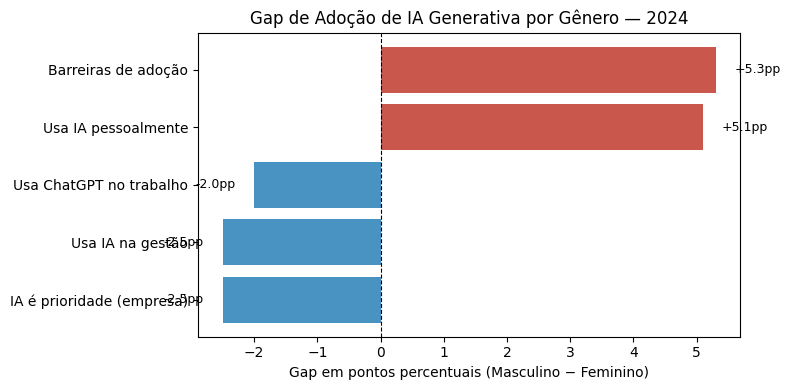

In [ ]:
df24_ia = binariza_ia(
    df[(df['ano_pesquisa'] == '2024') & df[IA_FEATS_ALL].notna().any(axis=1)],
    IA_FEATS_ALL,
)

print(f"Respondentes 2024 com dados de IA: {len(df24_ia):,}")
print(df24_ia.groupby('genero')[IA_FEATS_BIN].mean().mul(100).round(1)
      .rename(columns={c + '_bin': IA_LABELS[c] for c in IA_FEATS_ALL}).T)

tab_ia = (
    df24_ia.groupby('genero')[IA_FEATS_BIN]
    .mean().mul(100).round(1)
    .rename(columns={c + '_bin': IA_LABELS[c] for c in IA_FEATS_ALL})
)

gap = (tab_ia.loc['Masculino'] - tab_ia.loc['Feminino']).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C0392B' if v > 0 else '#2980B9' for v in gap.values]
bars = ax.barh(gap.index, gap.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, v in zip(bars, gap.values):
    ax.text(
        v + (0.3 if v >= 0 else -0.3),
        bar.get_y() + bar.get_height() / 2,
        f'{v:+.1f}pp', va='center',
        ha='left' if v >= 0 else 'right', fontsize=9,
    )
ax.set_xlabel('Gap em pontos percentuais (Masculino − Feminino)')
ax.set_title('Gap de Adoção de IA Generativa por Gênero — 2024')
plt.tight_layout()
plt.savefig('figures/2_9_ia_gap_genero.png', dpi=150, bbox_inches='tight')
plt.show()

# FILTRAR AS FEATURES DE EXPLORAÇÃO / VISAO GESTOR VISÃO PESSOAL

### 2.10 — Representatividade feminina por região

Análise complementar: a desigualdade de gênero tem padrão geográfico?  
Norte e Nordeste, com amostras menores, exigem cautela interpretativa  
(os `n` são exibidos explicitamente).


In [ ]:
df_reg = df[df['regiao'].isin(REGIOES)].copy()

fig = go.Figure()
for regiao in REGIOES:
    pcts, textos = [], []
    for ano in ANOS:
        sub = df_reg[(df_reg['regiao'] == regiao) & (df_reg['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        n   = ct.sum()
        fem = ct.get('Feminino', 0)
        v   = round(fem / n * 100, 1) if n >= 10 else None
        pcts.append(v)
        textos.append(f'{v}%' if v else 'n<10')
    fig.add_trace(go.Scatter(
        x=ANOS, y=pcts, mode='lines+markers+text', name=regiao,
        line=dict(color=CORES_REGIAO[regiao], width=2.5), marker=dict(size=9),
        text=textos, textposition='top center',
    ))
fmt(fig, '% Feminino por Região (2021–2024)', height=420)
fig.update_yaxes(ticksuffix='%', range=[0, 45])
fig.show()

# CRUZAMENTO AREA DE ORIGEM COM REGIAO - MIGROU?

---
### Síntese dos achados exploratórios


| Dimensão | Achado central | Relevância para a dissertação |
|---|---|---|
| Representatividade temporal | — | * |
| Cargo  | — | *|
| Senioridade  | — | * |
| Salário | — | *|
| Escolaridade | — | * |
| Área de formação | — | * |
| Experiência | — | * |
| Modalidade | — | * |
| Adoção de IA | — | * |
| Regional | — | * |


---
## Seção 3 — Análise Estatística 

A análise estatística foi estruturada em quatro etapas principais: estatística descritiva, testes de hipótese, análise de correlação e modelagem estatística.

Para investigar associações entre gênero e variáveis estruturais do mercado de dados, aplicou-se o teste Qui-Quadrado de independência, acompanhado do coeficiente V de Cramér para mensuração do tamanho do efeito. As análises envolveram relações entre gênero e senioridade, liderança e faixa salarial. O teste Qui-Quadrado foi utilizado para verificar a existência de dependência estatística entre variáveis categóricas, enquanto o V de Cramér permitiu avaliar a intensidade dessas associações.

Adicionalmente, aplicou-se a correlação de Spearman para avaliar relações monotônicas entre variáveis ordinais, especialmente entre senioridade, experiência e faixa salarial. A escolha desse método deve-se à natureza ordinal das variáveis analisadas e à ausência de pressupostos paramétricos.

Na etapa de modelagem estatística, foi utilizada regressão logística simples para analisar tendências temporais da participação feminina ao longo do período estudado, considerando o modelo genero ~ ano_pesquisa. 

*Principais Hipóteses Investigadas*

- H1 - Existe associação entre gênero e senioridade.

- H2 - Existe associação entre gênero e liderança.

- H3 - Existe diferença salarial entre gêneros.

- H4 - Senioridade e experiência estão associadas à remuneração.

- H5 - A participação feminina apresenta tendência temporal significativa entre 2021 e 2024.

In [97]:
df['genero_bin']         = (df['genero'] == 'Feminino').astype(int)
df['faixa_salarial_num'] = (
    df['faixa_salarial']
    .map({v: i for i, v in enumerate(FAIXA_SALARIAL_ORDEM)})
    .astype(float)
)
df['nivel_num'] = (
    df['nivel']
    .map({v: i for i, v in enumerate(NIVEL_SENIORIDADE_ORDEM)})
    .astype(float)
)
df['ano_num']    = df['ano_pesquisa'].astype(int)
df['ano_centro'] = df['ano_num'] - 2021  # centrado em 2021

variaveis_chi2 = {
    'Nível de Senioridade': 'nivel',
    'Faixa Salarial':       'faixa_salarial',
    'Nível de Ensino':      'nivel_ensino',
    'Cargo':                'cargo',
    'Modalidade':           'modalidade',
    'Situação':             'situacao',
    'Área de Formação':     'area_formacao',
    'Região':               'regiao',
}

print(f'N total:     {len(df):,}')
print(f'N Feminino:  {(df["genero"]=="Feminino").sum():,} ({(df["genero"]=="Feminino").mean()*100:.1f}%)')
print(f'N Masculino: {(df["genero"]=="Masculino").sum():,} ({(df["genero"]=="Masculino").mean()*100:.1f}%)')

N total:     17,295
N Feminino:  4,055 (23.4%)
N Masculino: 13,240 (76.6%)


### 3.1 — Qui-quadrado + V de Cramér  (H1, H2 e associações gerais)

Pressuposto checado: reporta % células com expected < 5. Regra prática: se > 20% das células com expected < 5, resultado deve ser interpretado com cautela (indicado na coluna 'Pressuposto OK').

In [98]:
def cramers_v(ct: pd.DataFrame) -> float:
    """V de Cramér com correção de viés (Bergsma & Wicher, 2013)."""
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, c = ct.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (c - 1) / (n - 1))
    r_corr    = r - (r - 1) ** 2 / (n - 1)
    c_corr    = c - (c - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, c_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0


def teste_qui_quadrado(df: pd.DataFrame, col: str, label: str) -> dict:
    sub      = df.dropna(subset=[col, 'genero'])
    ct       = pd.crosstab(sub[col], sub['genero'])
    chi2, p, dof, expected = chi2_contingency(ct)
    v        = cramers_v(ct)
    pct_ok   = (expected >= 5).mean() * 100
    return {
        'Variável':            label,
        'N':                   len(sub),
        'χ²':                  round(chi2, 3),
        'gl':                  dof,
        'p-valor':             round(p, 6),
        'Significativo':       'Sim' if p < ALPHA else 'Não',
        'V de Cramér':         round(v, 4),
        'Magnitude':           ('Forte' if v >= .4 else 'Moderado' if v >= .2
                                 else 'Pequeno' if v >= .1 else 'Negligenciável'),
        '% células (exp≥5)':   f'{pct_ok:.0f}%',
        'Pressuposto OK':      'Sim' if pct_ok >= 80 else 'Atenção',
    }


tab_chi2 = pd.DataFrame(
    [teste_qui_quadrado(df, col, label) for label, col in variaveis_chi2.items()]
).set_index('Variável')

print('\n=== H1/H2 — Qui-quadrado + V de Cramér ===')
print(tab_chi2.to_string())



=== H1/H2 — Qui-quadrado + V de Cramér ===
                          N       χ²  gl   p-valor Significativo  V de Cramér       Magnitude % células (exp≥5) Pressuposto OK
Variável                                                                                                                      
Nível de Senioridade  12422   47.763   2  0.000000           Sim       0.0607  Negligenciável              100%            Sim
Faixa Salarial        15438  184.015  11  0.000000           Sim       0.1059         Pequeno              100%            Sim
Nível de Ensino       17269   89.471   5  0.000000           Sim       0.0699  Negligenciável              100%            Sim
Cargo                 12422  139.500   6  0.000000           Sim       0.1037         Pequeno              100%            Sim
Modalidade            15557   60.570   3  0.000000           Sim       0.0608  Negligenciável              100%            Sim
Situação              17295  118.078   9  0.000000           Sim   

### 3.2 — Mann-Whitney U  (H3: diferença salarial entre gêneros)

Decisão metodológica: two-sided — sem hipótese direcional a priori.
Effect size: rank-biserial correlation r = 2U/(n1*n2) - 1, ∈ [-1, 1].
  r > 0  → masculino tende a salários maiores
  r < 0  → feminino tende a salários maiores
Magnitude (Cohen): |r| < .1 negligenciável, .1–.3 pequeno,
                   .3–.5 médio, ≥ .5 grande.
Múltiplos subgrupos (por ano e região) são descritivos, não inferenciais
adicionais — sem correção de múltiplas comparações aplicada.

In [99]:
def rank_biserial(U: float, n1: int, n2: int) -> float:
    """Rank-biserial correlation para two-sided Mann-Whitney.

    r = 2U/(n1*n2) - 1
    Equivalente a: (proporção de pares onde grupo 1 > grupo 2) * 2 - 1.
    Intervalo: [-1, 1]; r=0 indica distribuições equivalentes.
    """
    return (2 * U) / (n1 * n2) - 1


def mann_whitney_salarial(df_sub: pd.DataFrame, label: str = 'Geral') -> dict | None:
    sub  = df_sub.dropna(subset=['faixa_salarial_num', 'genero'])
    masc = sub[sub['genero'] == 'Masculino']['faixa_salarial_num']
    fem  = sub[sub['genero'] == 'Feminino' ]['faixa_salarial_num']
    if len(masc) < 5 or len(fem) < 5:
        return None

    # two-sided: sem hipótese direcional a priori (H0: distribuições iguais)
    U, p = mannwhitneyu(masc, fem, alternative='two-sided')
    r    = rank_biserial(U, len(masc), len(fem))

    return {
        'Grupo':             label,
        'N Masc':            len(masc),
        'N Fem':             len(fem),
        'Mediana Masc':      FAIXA_SALARIAL_ORDEM[int(masc.median())],
        'Mediana Fem':       FAIXA_SALARIAL_ORDEM[int(fem.median())],
        'U':                 round(U),
        'p-valor':           round(p, 6),
        'Significativo':     'Sim' if p < ALPHA else 'Não',
        'r (rank-biserial)': round(r, 4),
        'Direção':           ('Masc > Fem' if r > 0 else 'Fem > Masc' if r < 0 else 'Neutro'),
        'Magnitude':         ('Grande' if abs(r) >= .5 else 'Médio'  if abs(r) >= .3
                               else 'Pequeno' if abs(r) >= .1 else 'Negligenciável'),
    }


res_mw = [mann_whitney_salarial(df, 'Brasil — Geral')]
for ano in ANOS:
    res_mw.append(mann_whitney_salarial(df[df['ano_pesquisa'] == ano], f'{ano}'))
for reg in sorted(df['regiao'].dropna().unique()):
    res_mw.append(mann_whitney_salarial(df[df['regiao'] == reg], f'Região: {reg}'))

tab_mw = pd.DataFrame([r for r in res_mw if r]).set_index('Grupo')
print('\n=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===')
print(tab_mw.to_string())



=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===
                      N Masc  N Fem Mediana Masc Mediana Fem         U   p-valor Significativo  r (rank-biserial)     Direção       Magnitude
Grupo                                                                                                                                        
Brasil — Geral         11900   3538     R$8k-12k     R$6k-8k  23712840  0.000000           Sim             0.1264  Masc > Fem         Pequeno
2021                    1892    430      R$6k-8k     R$6k-8k    454266  0.000131           Sim             0.1167  Masc > Fem         Pequeno
2022                    2749    876     R$8k-12k     R$6k-8k   1349824  0.000000           Sim             0.1211  Masc > Fem         Pequeno
2023                    3597   1099     R$8k-12k     R$6k-8k   2236891  0.000000           Sim             0.1317  Masc > Fem         Pequeno
2024                    3662   1133     R$8k-12k    R$8k-12k   2376175  0.000000        

### 3.3 — Correlação de Spearman  (H4: senioridade × remuneração)

Cobre H4 de forma mais direta que Kruskal-Wallis para variáveis ordinais:
mede a força e direção da associação monotônica entre nível e salário,
separando os grupos para avaliar se o gradiente difere por gênero.

In [100]:
def spearman_por_genero(df: pd.DataFrame, x: str, y: str,
                         label_x: str, label_y: str) -> pd.DataFrame:
    rows = []
    for genero in ['Masculino', 'Feminino', 'Geral']:
        sub = df if genero == 'Geral' else df[df['genero'] == genero]
        sub = sub.dropna(subset=[x, y])
        if len(sub) < 10:
            continue
        rho, p = spearmanr(sub[x], sub[y])
        rows.append({
            'Grupo':         genero,
            'N':             len(sub),
            f'ρ ({label_x} × {label_y})': round(rho, 4),
            'p-valor':       round(p, 6),
            'Significativo': 'Sim' if p < ALPHA else 'Não',
            'Magnitude':     ('Forte' if abs(rho) >= .5 else 'Moderada' if abs(rho) >= .3
                               else 'Fraca' if abs(rho) >= .1 else 'Negligenciável'),
        })
    return pd.DataFrame(rows).set_index('Grupo')


# H4a: nível de senioridade × faixa salarial
tab_sp_nivel_sal = spearman_por_genero(
    df, 'nivel_num', 'faixa_salarial_num',
    'Senioridade', 'Salário'
)

# H4b: experiência × faixa salarial (complementar, se a coluna existir)
if 'tempo_area_dados' in df.columns:
    cats = [
        'Menos de 1 ano', 'de 1 a 2 anos', 'de 2 a 3 anos', 'de 3 a 4 anos',
        'de 4 a 5 anos', 'de 5 a 6 anos', 'de 6 a 7 anos', 'de 7 a 10 anos',
        'Mais de 10 anos',
    ]
    codes = pd.Categorical(df['tempo_area_dados'], categories=cats, ordered=True).codes.astype(float)
    codes[codes == -1] = np.nan
    df['experiencia_num'] = codes

    tab_sp_exp_sal = spearman_por_genero(df, 'experiencia_num', 'faixa_salarial_num', 'Experiência', 'Salário')
else:
    tab_sp_exp_sal = pd.DataFrame()

print('\n=== H4 — Spearman: Senioridade × Salário ===')
print(tab_sp_nivel_sal.to_string())

if not tab_sp_exp_sal.empty:
    print('\n=== H4 — Spearman: Experiência × Salário ===')
    print(tab_sp_exp_sal.to_string())


=== H4 — Spearman: Senioridade × Salário ===
               N  ρ (Senioridade × Salário)  p-valor Significativo Magnitude
Grupo                                                                       
Masculino   9342                     0.7220      0.0           Sim     Forte
Feminino    2979                     0.7178      0.0           Sim     Forte
Geral      12321                     0.7221      0.0           Sim     Forte

=== H4 — Spearman: Experiência × Salário ===
               N  ρ (Experiência × Salário)  p-valor Significativo Magnitude
Grupo                                                                       
Masculino  10409                     0.6566      0.0           Sim     Forte
Feminino    3108                     0.6296      0.0           Sim     Forte
Geral      13517                     0.6522      0.0           Sim     Forte


### 3.4 — Regressão Logística Simples — Tendência Temporal  (H5)

Modelo: P(Feminino) ~ ano_centro
ano_centro = ano - 2021 (centrado para facilitar interpretação do intercepto)
Reporta OR, IC 95% e pseudo-R² de McFadden.

In [101]:
def regressao_temporal(df_sub: pd.DataFrame, label: str = 'Brasil') -> dict | None:
    sub = df_sub.dropna(subset=['genero_bin', 'ano_centro'])
    if len(sub) < 50:
        return None
    X   = sm.add_constant(sub['ano_centro'])
    mod = sm.Logit(sub['genero_bin'], X).fit(disp=False)

    coef = mod.params['ano_centro']
    p    = mod.pvalues['ano_centro']
    OR   = np.exp(coef)
    ci   = np.exp(mod.conf_int().loc['ano_centro'])
    llf  = mod.llf
    llnull = mod.llnull
    mcfadden_r2 = 1 - llf / llnull  # pseudo-R² de McFadden

    return {
        'Grupo':            label,
        'N':                len(sub),
        'β (log-odds/ano)': round(coef, 4),
        'OR':               round(OR, 4),
        'IC 95% OR':        f'[{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}]',
        'p-valor':          round(p, 6),
        'Significativo':    'Sim' if p < ALPHA else 'Não',
        'McFadden R²':      round(mcfadden_r2, 4),
        'Tendência':        ('Crescente'  if coef > 0 and p < ALPHA
                              else 'Decrescente' if coef < 0 and p < ALPHA
                              else 'Estável'),
    }


res_temp = [regressao_temporal(df, 'Brasil — Geral')]
for reg in sorted(df['regiao'].dropna().unique()):
    res_temp.append(regressao_temporal(df[df['regiao'] == reg], f'Região: {reg}'))

tab_temp = pd.DataFrame([r for r in res_temp if r]).set_index('Grupo')
print('\n=== H5 — Tendência Temporal da Representatividade Feminina ===')
print(tab_temp.to_string())


=== H5 — Tendência Temporal da Representatividade Feminina ===
                          N  β (log-odds/ano)      OR       IC 95% OR   p-valor Significativo  McFadden R²  Tendência
Grupo                                                                                                                
Brasil — Geral        17295            0.0585  1.0603  [1.025, 1.097]  0.000711           Sim       0.0006  Crescente
Região: Centro-Oeste   1071            0.1135  1.1202  [0.971, 1.292]  0.119501           Não       0.0023    Estável
Região: Nordeste       1971            0.0407  1.0415  [0.940, 1.155]  0.439353           Não       0.0003    Estável
Região: Norte           256           -0.0507  0.9505  [0.691, 1.308]  0.755645           Não       0.0004    Estável
Região: Sudeste       10542            0.0557  1.0573  [1.013, 1.103]  0.010410           Sim       0.0006  Crescente
Região: Sul            3044            0.0722  1.0748  [0.989, 1.169]  0.090758           Não       0.0009    

In [102]:
with pd.ExcelWriter('resultados_estatisticos.xlsx') as writer:
    tab_chi2.to_excel(writer,          sheet_name='Chi2 e Cramer V')
    tab_mw.to_excel(writer,            sheet_name='Mann-Whitney Salarial')
    tab_sp_nivel_sal.to_excel(writer,  sheet_name='Spearman Nivel x Salario')
    if not tab_sp_exp_sal.empty:
        tab_sp_exp_sal.to_excel(writer, sheet_name='Spearman Exp x Salario')
    tab_temp.to_excel(writer,          sheet_name='Tendencia Temporal')

print('\n resultados_estatisticos.xlsx salvo')


 resultados_estatisticos.xlsx salvo


---
## Seção 4 — Modelagem Preditiva (Machine Learning)

### Estratégia

| Aspecto | Decisão |
|---|---|
| Treino | 2021–2023 (**inclui features de IA de 2023**) |
| Teste  | 2024 (**inclui features de IA de 2024**) |
| Targets | Faixa Salarial · Senioridade · Gestor/a |
| Modelos | Logistic Regression · Random Forest · XGBoost |
| Seleção | Melhor F1-macro em CV 5-fold estratificado |

> **Modelo A:** treino 2021–2023 sem IA / teste 2024 sem IA — baseline  
> **Modelo B:** treino 2021–2023 **com IA de 2023** / teste 2024 **com IA de 2024** — comparação honesta
>
> A comparação A vs B responde: **"IA generativa é preditor relevante de salário/senioridade?"**

In [ ]:
# REFORMULAR A IDEIA DE PREDIÇÃO E TER CLAREZA DO QUE QUERO DESCOBRIR COM AS COLUNAS DE IA

In [103]:
BASE_FEATURES = [
    'nivel_ensino', 'area_formacao', 'cargo',
    'tempo_area_dados', 'tempo_area_ti', 'modalidade',
    'setor', 'regiao', 'situacao',
]
TARGETS = {
    'faixa_salarial': 'multiclass',
    'nivel':          'multiclass',
    'gestor':         'binario',
}
TARGET_LABELS = {
    'faixa_salarial': 'Faixa Salarial',
    'nivel':          'Senioridade',
    'gestor':         'Gestor/a',
}
ORDEM_MAP = {
    'faixa_salarial': FAIXA_SALARIAL_ORDEM,
    'nivel':          NIVEL_SENIORIDADE_ORDEM,
}

In [104]:
def prepare_xy(df, target, extra_features=None):
    exclude = {'gestor': ['nivel', 'cargo']}
    feats = [f for f in BASE_FEATURES if f not in exclude.get(target, [])]
    if extra_features:
        feats += [f for f in extra_features if f in df.columns]

    sub = df[feats + [target, 'genero', 'ano_pesquisa']].copy()

    codes = pd.Categorical(
        sub['nivel_ensino'], categories=NIVEL_ENSINO_ORDEM, ordered=True
    ).codes.astype(float)
    codes[codes == -1] = np.nan
    sub['nivel_ensino'] = codes

    if target == 'gestor':
        sub['y'] = pd.to_numeric(sub[target], errors='coerce')
    else:
        codes = pd.Categorical(
            sub[target], categories=ORDEM_MAP[target], ordered=True
        ).codes.astype(float)
        codes[codes == -1] = np.nan
        sub['y'] = codes

    sub = sub.dropna(subset=['y'])
    return sub[feats].copy(), sub['y'].astype(int), sub[['genero', 'ano_pesquisa']].copy()

In [105]:
def build_preprocessor(X):
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(exclude='number').columns.tolist()
    steps = []
    if num_cols:
        steps.append(('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), num_cols))
    if cat_cols:
        steps.append(('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols))
    return ColumnTransformer(steps, remainder='drop')


def get_models(task_type):
    kw = dict(random_state=SEED)
    binary = task_type == 'binario'
    return {
        'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', **kw),
        'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, **kw),
        'XGBoost':             XGBClassifier(n_estimators=200, verbosity=0, **kw,
                                   eval_metric='logloss' if binary else 'mlogloss',
                                   **(dict(scale_pos_weight=5) if binary else {})),
    }

In [106]:
def run_cv(X, y, task_type, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    rows = []
    for name, model in get_models(task_type).items():
        scores = cross_val_score(Pipeline([('pre', build_preprocessor(X)), ('clf', model)]),
                                 X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        rows.append({'Modelo': name, 'F1_mean': scores.mean(), 'F1_std': scores.std()})
        print(f'    {name:22s}: {scores.mean():.3f} ± {scores.std():.3f}')
    return pd.DataFrame(rows)


def treinar_avaliar(target, task_type, df_train, df_test, extra_features=None, label_extra=''):
    tag = TARGET_LABELS[target] + (f' {label_extra}' if label_extra else '')
    print(f'\n{"="*55}\n  {tag}\n{"="*55}')

    X_tr, y_tr, _    = prepare_xy(df_train, target, extra_features)
    X_te, y_te, meta = prepare_xy(df_test,  target, extra_features)
    print(f'  Treino: {len(X_tr):,} | Teste: {len(X_te):,} | Classes: {sorted(y_tr.unique())}')

    cv_df     = run_cv(X_tr, y_tr, task_type)
    best_name = cv_df.loc[cv_df['F1_mean'].idxmax(), 'Modelo']
    print(f'  → {best_name}')

    pipe = Pipeline([('pre', build_preprocessor(X_tr)), ('clf', get_models(task_type)[best_name])])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    print(classification_report(y_te, y_pred, zero_division=0))

    rows = [{'Gênero': g, 'N': int((m := meta['genero'] == g).sum()),
             'F1_macro': round(f1_score(y_te[m], y_pred[m], average='macro', zero_division=0), 4)}
            for g in ['Masculino', 'Feminino'] if (meta['genero'] == g).any()]
    print(pd.DataFrame(rows).to_string(index=False))

    return dict(target=target, label=tag, best_name=best_name, pipe=pipe,
                X_tr=X_tr, X_te=X_te, y_te=y_te, y_pred=y_pred, meta=meta)

In [107]:
df_train = pd.read_parquet('data/df_train.parquet')
df_test  = pd.read_parquet('data/df_test.parquet')

print(f'df_train: {len(df_train):,} linhas — anos {sorted(df_train["ano_pesquisa"].unique())}')
print(f'df_test:  {len(df_test):,} linhas — anos {sorted(df_test["ano_pesquisa"].unique())}')

ia_treino = [c for c in IA_FEATS_ALL if c in df_train.columns and df_train[c].notna().any()]
ia_teste  = [c for c in IA_FEATS_ALL if c in df_test.columns  and df_test[c].notna().any()]

def cobertura(df, cols):
    return df[cols].notna().any(axis=1).mean() * 100 if cols else 0.0

print(f'\nIA treino: {len(ia_treino)}/{len(IA_FEATS_ALL)} features — {cobertura(df_train, ia_treino):.1f}% das linhas')
print(f'IA teste:  {len(ia_teste)}/{len(IA_FEATS_ALL)} features — {cobertura(df_test,  ia_teste):.1f}% das linhas')

df_train: 12,117 linhas — anos ['2021', '2022', '2023']
df_test:  5,178 linhas — anos ['2024']

IA treino: 5/5 features — 38.3% das linhas
IA teste:  5/5 features — 89.5% das linhas


In [108]:
results_A = {}
for target, task_type in TARGETS.items():
    results_A[target] = treinar_avaliar(
        target, task_type, df_train, df_test, label_extra='[A]',
    )


  Faixa Salarial [A]
  Treino: 10,643 | Teste: 4,795 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
    Logistic Regression   : 0.262 ± 0.007
    Random Forest         : 0.265 ± 0.011
    XGBoost               : 0.262 ± 0.010
  → Random Forest
              precision    recall  f1-score   support

           0       0.51      0.68      0.58       151
           1       0.26      0.23      0.25       235
           2       0.19      0.16      0.18       268
           3       0.31      0.35      0.33       592
           4       0.23      0.18      0.20       649
           5       0.37      0.50      0.42      1070
           6       0.30      0.34      0.32       714
           7       0.27      0.16      0.20       453
           8       0.18      0.13      0.15       246
           9       0.22      0.13      0.16       159
          10       0.22      0.12    

In [109]:
ia_comum = [c for c in IA_FEATS_ALL if c in ia_treino and c in ia_teste]
print(f'Features de IA comuns (treino ∩ teste): {len(ia_comum)}')

results_B = {}
for target, task_type in TARGETS.items():
    results_B[target] = treinar_avaliar(
        target, task_type, df_train, df_test, extra_features=ia_comum, label_extra='[B]',
    )

Features de IA comuns (treino ∩ teste): 5

  Faixa Salarial [B]
  Treino: 10,643 | Teste: 4,795 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
    Logistic Regression   : 0.257 ± 0.002
    Random Forest         : 0.255 ± 0.007
    XGBoost               : 0.266 ± 0.007
  → XGBoost
              precision    recall  f1-score   support

           0       0.51      0.66      0.57       151
           1       0.29      0.26      0.27       235
           2       0.19      0.16      0.18       268
           3       0.30      0.37      0.33       592
           4       0.24      0.14      0.18       649
           5       0.37      0.50      0.42      1070
           6       0.28      0.33      0.30       714
           7       0.26      0.16      0.20       453
           8       0.18      0.17      0.17       246
           9       0.14      0.11      0.12       159
 

obs: Gestor/a ainda tem leakage no Modelo B. Provavelmente colunas sobre ia que só aparecem preenchidas para quem é gestor. -- AJUSTAR

---
## Seção 5 — Explicabilidade com SHAP

In [110]:
def compute_shap(pipe, X, model_name, max_samples=600):
    pre = pipe.named_steps['pre']
    clf = pipe.named_steps['clf']

    idx = np.random.RandomState(SEED).choice(len(X), min(max_samples, len(X)), replace=False)
    X_s = X.iloc[idx]
    X_t = pre.transform(X_s)

    try:
        feat_names = [n.replace('cat__', '').replace('num__', '')
                      for n in pre.get_feature_names_out()]
    except Exception:
        feat_names = [f'f{i}' for i in range(X_t.shape[1])]

    if 'XGBoost' in model_name or 'Random Forest' in model_name:
        explainer = shap.TreeExplainer(clf)
    else:
        explainer = shap.LinearExplainer(clf, shap.maskers.Independent(X_t))

    return explainer(X_t), feat_names

In [111]:
def plot_shap(shap_exp, feat_names, top_n=15, title='SHAP', fname='shap.png', highlight_ia=False):
    shap_exp.feature_names = feat_names

    # multiclasse: média dos valores absolutos entre classes
    if shap_exp.values.ndim == 3:
        values = np.mean(np.abs(shap_exp.values), axis=2)
        exp = shap.Explanation(values=values, data=shap_exp.data, feature_names=feat_names)
    else:
        exp = shap_exp

    plt.figure()
    shap.plots.beeswarm(exp, max_display=top_n, show=False)

    ax = plt.gca()
    ax.set_title(title, fontweight='bold', loc='left', pad=10)

    if highlight_ia:
        for label in ax.get_yticklabels():
            if 'ia_' in label.get_text():
                label.set_color('#F4A43B')
                label.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'   figures/{fname}')

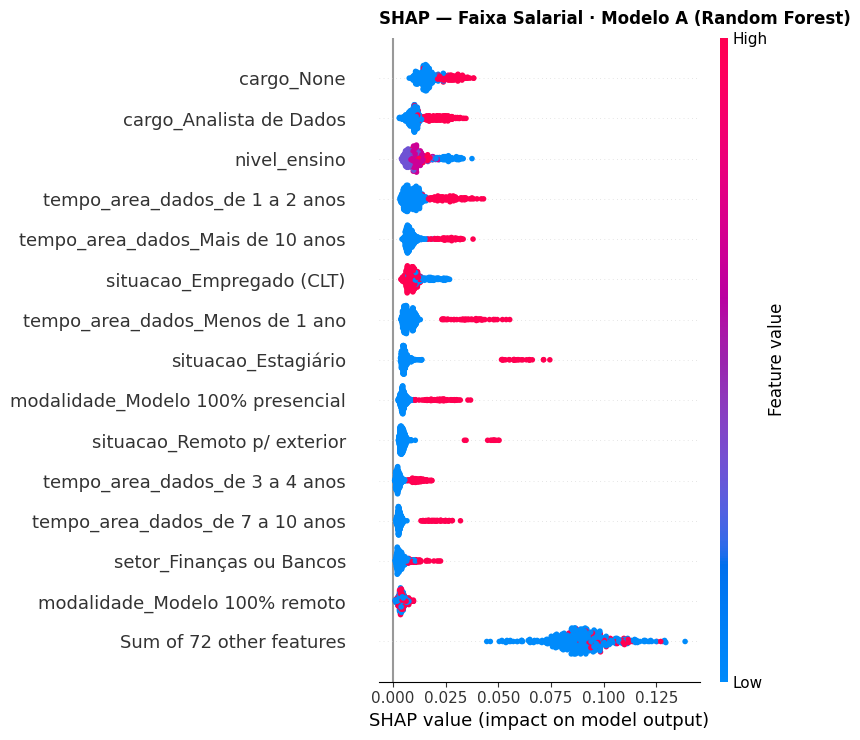

   figures/shap_A_faixa_salarial.png


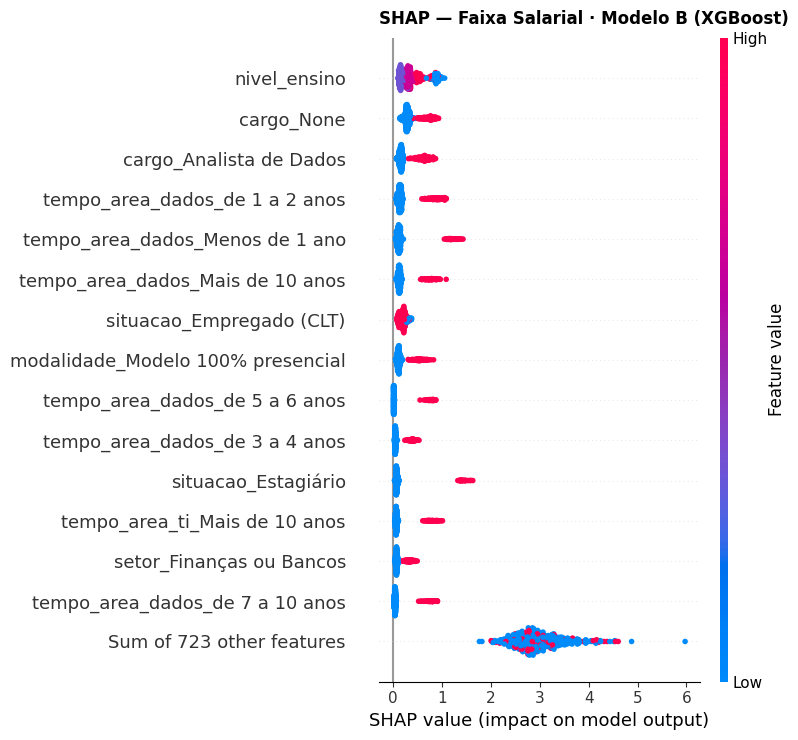

   figures/shap_B_faixa_salarial.png


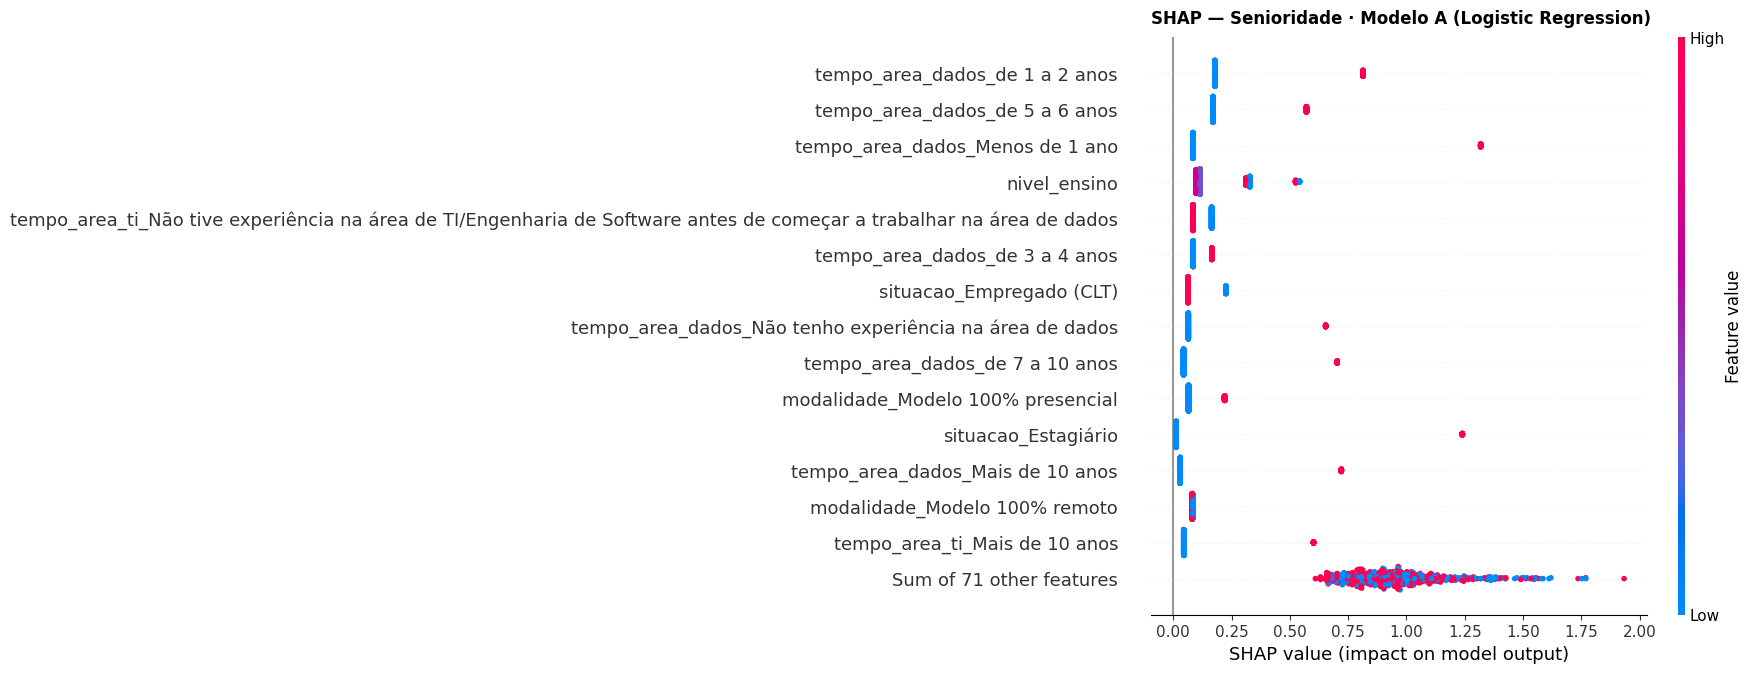

   figures/shap_A_nivel.png


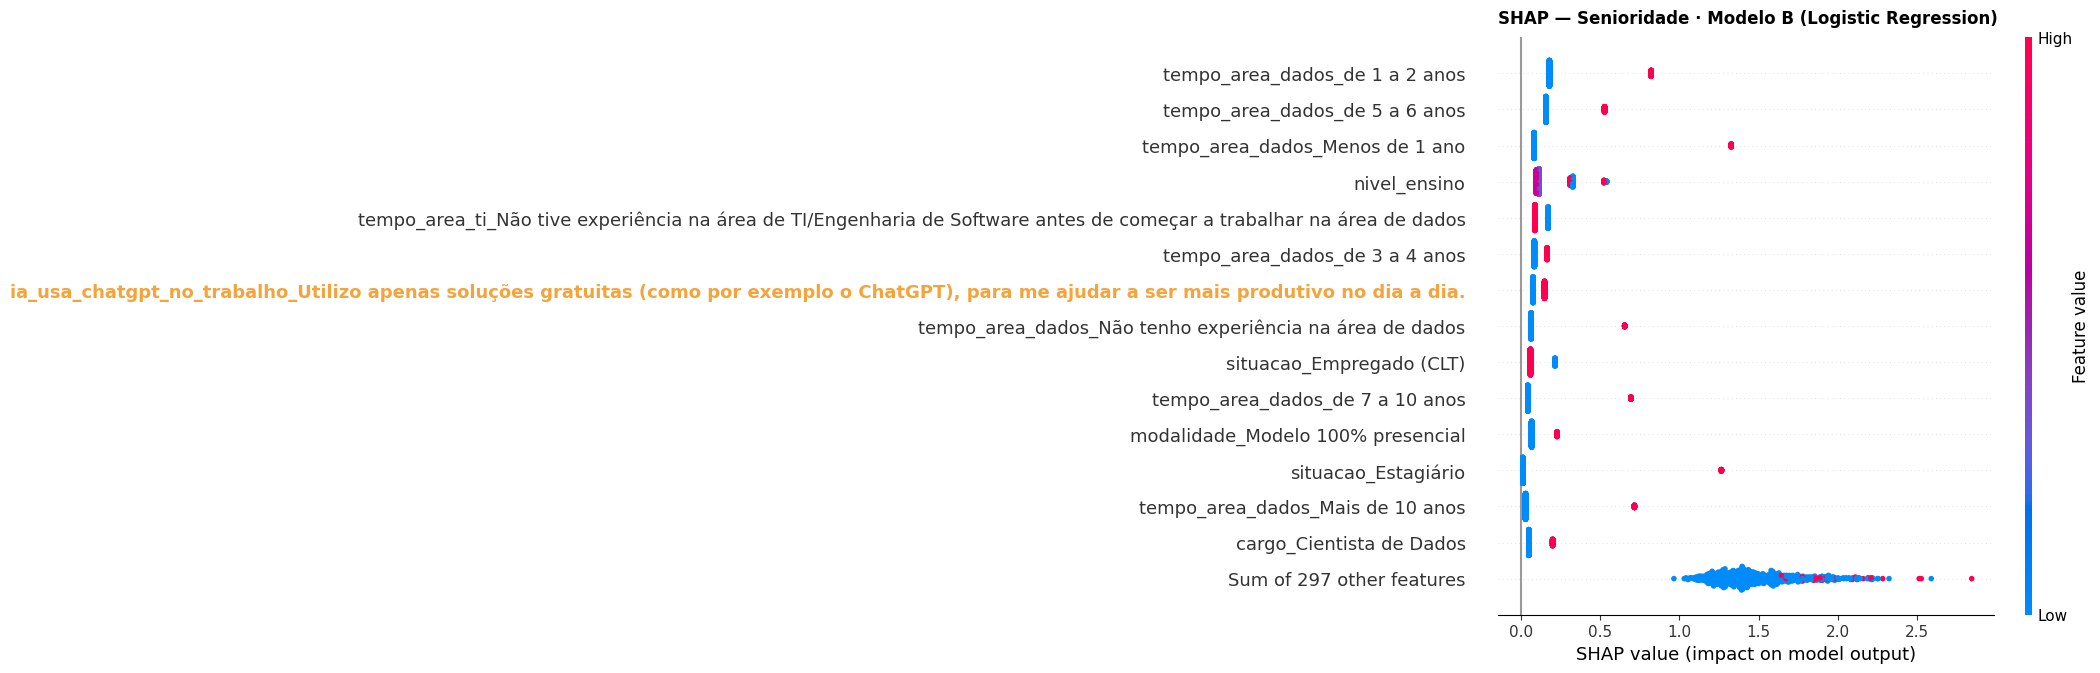

   figures/shap_B_nivel.png


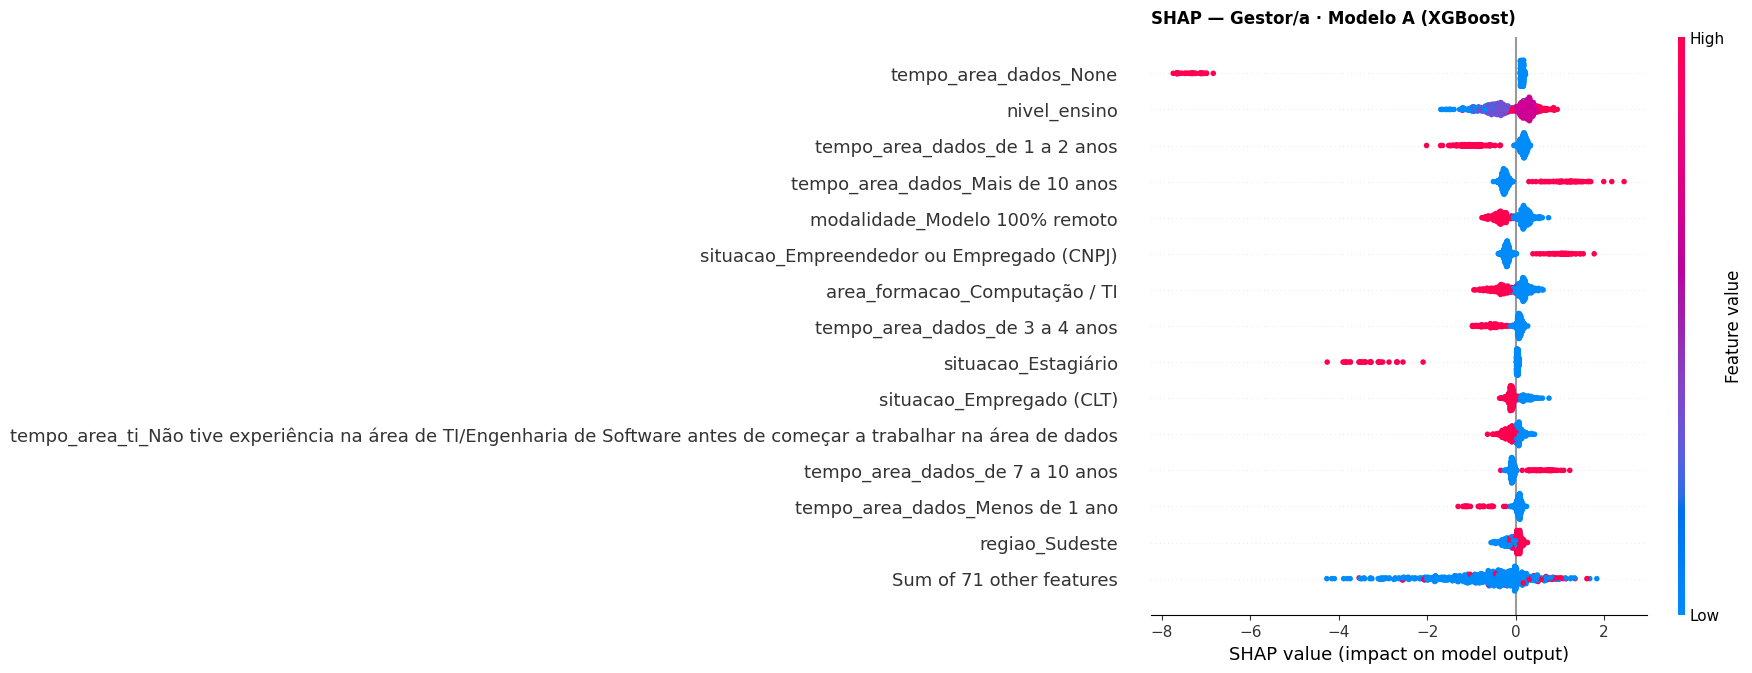

In [ ]:
shap_cache = {}
for target in TARGETS:
    for key, results, hl in [('A', results_A, False), ('B', results_B, True)]:
        r = results[target]
        try:
            exp, feat_names = compute_shap(r['pipe'], r['X_te'], r['best_name'])
            shap_cache[f'{key}_{target}'] = (exp, feat_names)
            plot_shap(exp, feat_names,
                      title=f'SHAP — {TARGET_LABELS[target]} · Modelo {key} ({r["best_name"]})',
                      fname=f'shap_{key}_{target}.png',
                      highlight_ia=hl)
        except Exception as e:
            print(f'  SHAP {key}/{target}: {e}')

In [ ]:
def compute_shap(pipe, X, model_name, max_samples=600):
    pre = pipe.named_steps['pre']
    clf = pipe.named_steps['clf']

    X_t = pre.transform(X)
    try:
        feat_names = np.array(pre.get_feature_names_out())
    except Exception:
        feat_names = np.array([f'f{i}' for i in range(X_t.shape[1])])

    idx = np.random.RandomState(SEED).choice(X_t.shape[0], min(max_samples, X_t.shape[0]), replace=False)
    X_s = X_t[idx]

    if 'XGBoost' in model_name or 'Random Forest' in model_name:
        sv = shap.TreeExplainer(clf).shap_values(X_s)
    else:
        masker = shap.maskers.Independent(X_s)
        sv = shap.LinearExplainer(clf, masker).shap_values(X_s)

    # sv pode ser lista (multiclasse) ou array 2-D (binário/LR)
    if isinstance(sv, list):
        mean_abs = np.mean([np.abs(s) for s in sv], axis=0).mean(axis=0)
    else:
        sv = np.array(sv)
        mean_abs = np.abs(sv).mean(axis=0)
        if mean_abs.ndim > 1:
            mean_abs = mean_abs.mean(axis=0)

    return mean_abs, feat_names


def clean_feat_name(name: str) -> str:
    return name.replace('cat__', '').replace('num__', '')


def is_ia_feature(name: str) -> bool:
    # Detecta features de IA mesmo após OHE (ex: "cat__ia_prioridade_empresa_Sim")
    return 'ia_' in name


def plot_shap_bar(mean_shap, feat_names, top_n=15, title='SHAP', fname='shap.png', highlight_ia=False):
    top_idx  = np.argsort(mean_shap)[::-1][:top_n]
    names_r  = feat_names[top_idx]
    vals     = mean_shap[top_idx]
    names_c  = [clean_feat_name(n) for n in names_r]
    colors   = ['#F4A43B' if is_ia_feature(n) else '#4C8FBF' for n in names_r] if highlight_ia else ['#4C8FBF'] * len(names_r)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(names_c[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(title, fontweight='bold', loc='left')
    if highlight_ia:
        ax.legend(handles=[
            mpatches.Patch(color='#F4A43B', label='Feature de IA generativa'),
            mpatches.Patch(color='#4C8FBF', label='Feature base'),
        ], loc='lower right', frameon=False)
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'   figures/{fname}')


print(' Funções SHAP definidas')


✅ Funções SHAP definidas


In [ ]:
shap_cache = {}
for target in TARGETS:
    safe = target.replace(' ', '_')
    for key, results, hl in [('A', results_A, False), ('B', results_B, True)]:
        try:
            r = results[target]
            ms, fn = compute_shap(r['pipe'], r['X_test'], r['best_name'])
            shap_cache[f'{key}_{target}'] = (ms, fn)
            plot_shap_bar(ms, fn,
                title=f'SHAP — {TARGET_LABELS[target]} · Modelo {key} ({r["best_name"]})',
                fname=f'shap_{key}_{safe}.png', highlight_ia=hl)
        except Exception as e:
            print(f'⚠️ SHAP Modelo {key} / {target}: {e}')

In [ ]:
def plot_shap_comparacao(target, top_n=12):
    """Compara lado a lado o SHAP do Modelo A (sem IA) e B (com IA)."""
    key_a, key_b = f'A_{target}', f'B_{target}'
    if key_a not in shap_cache or key_b not in shap_cache:
        print(f'⚠️ SHAP não disponível para {target}'); return
    clean = lambda n: n.replace('cat__', '').replace('num__', '')
    def top(ms, fn, n):
        idx = np.argsort(ms)[::-1][:n]
        return [clean(fn[i]) for i in idx], ms[idx]
    ms_a, fn_a = shap_cache[key_a]; ms_b, fn_b = shap_cache[key_b]
    names_a, vals_a = top(ms_a, fn_a, top_n)
    names_b, vals_b = top(ms_b, fn_b, top_n)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, names, vals, subtitle, hl in [
        (axes[0], names_a, vals_a, 'Modelo A (sem IA)', False),
        (axes[1], names_b, vals_b, 'Modelo B (com IA de 2023 e 2024)', True),
    ]:
        colors = ['#F4A43B' if 'ia_' in n else '#4C8FBF' for n in names] if hl else ['#4C8FBF']*len(names)
        ax.barh(names[::-1], vals[::-1], color=colors[::-1])
        ax.set_xlabel('Mean |SHAP value|'); ax.set_title(subtitle, fontweight='bold')
    fig.suptitle(f'SHAP Comparativo — {TARGET_LABELS[target]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'figures/shap_comp_{target}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  💾 {fname}')

for target in TARGETS:
    plot_shap_comparacao(target)